# Próbkowanie sygnałów cyfrowych

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

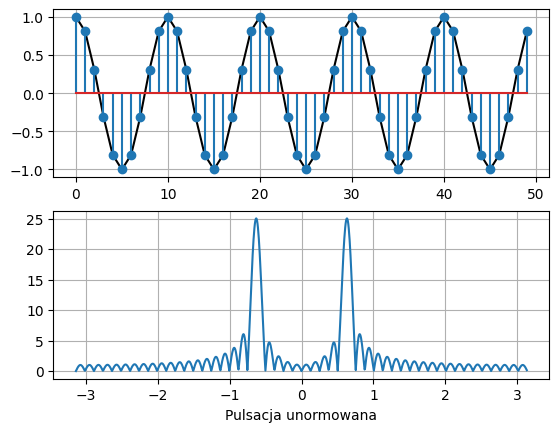

In [ ]:
f   = 0.1e6   # Częstotliwość sygnału analogowego
fs  = 1e6     # Częstotliwość próbkowania
Ts  = 1/fs

N = 50            # Liczba próbek
n = np.arange(N)  # Tablica indeksów
t = n*Ts

s = np.cos(2*np.pi*f*t)
#s = np.cos(2*np.pi*f/fs * n)

Nfft = 1024
F = np.arange(Nfft)/Nfft - 0.5
f_ = F*fs
W = F * 2*np.pi
S = np.fft.fftshift(np.fft.fft(s, Nfft))

plt.subplot(2,1,1)
plt.plot(s, '-k')
plt.stem(s)
plt.grid('on')

plt.subplot(2,1,2)
plt.plot(W, np.abs(S))
plt.xlabel('Pulsacja unormowana')
plt.grid('on')

## Aliasing

(-100.0, 100.0)

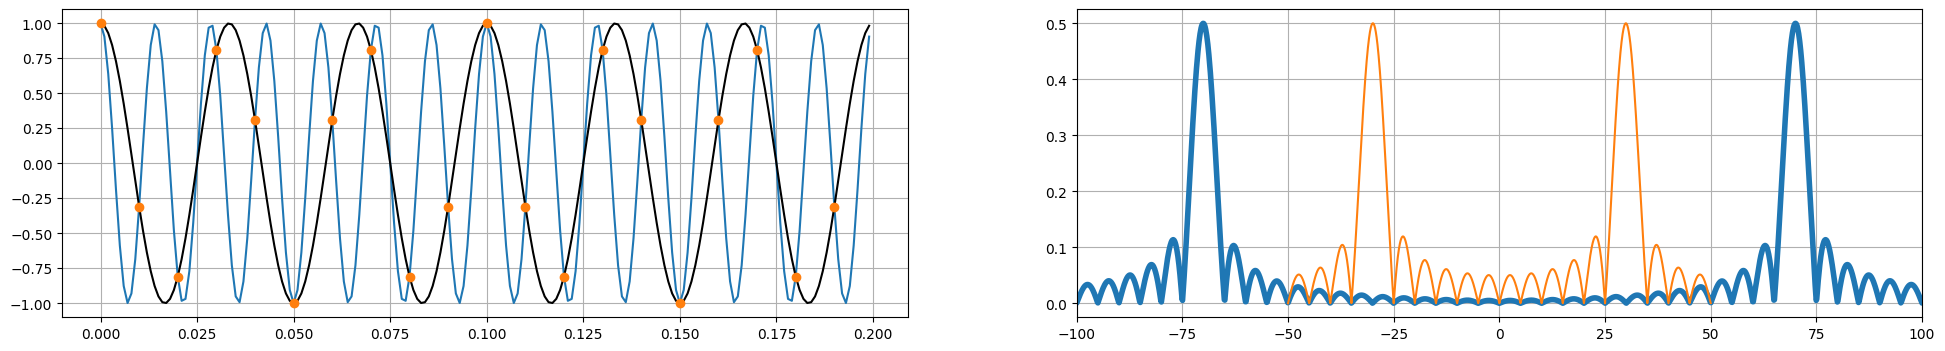

In [ ]:
fs = 1000
t = np.arange(200)/fs

f = 70

s = np.cos(2*np.pi*f*t)

Nfft = 8192
S = np.fft.fftshift(np.fft.fft(s, Nfft) / s.shape[0])
fv = np.fft.fftshift(np.fft.fftfreq(Nfft, 1/fs))

stride = 10
s_ = s[::stride]
t_ = t[::stride]

fa = fs/stride - f
sa = np.cos(2*np.pi*fa*t)

S_ = np.fft.fftshift(np.fft.fft(s_, Nfft) / s_.shape[0])
fv_ = np.fft.fftshift(np.fft.fftfreq(Nfft, stride/fs))

plt.figure(figsize=(24,4))
plt.subplot(121)
plt.plot(t, s)
plt.plot(t, sa, '-k')
plt.plot(t_, s_, 'o')
plt.grid('on')

plt.subplot(122)
plt.plot(fv, np.abs(S), linewidth = 4)
plt.plot(fv_, np.abs(S_))
plt.grid('on')
plt.xlim([-100, 100])

## Nadpróbkowanie

Text(0.5, 0, 'Częstotliwość unormowana')

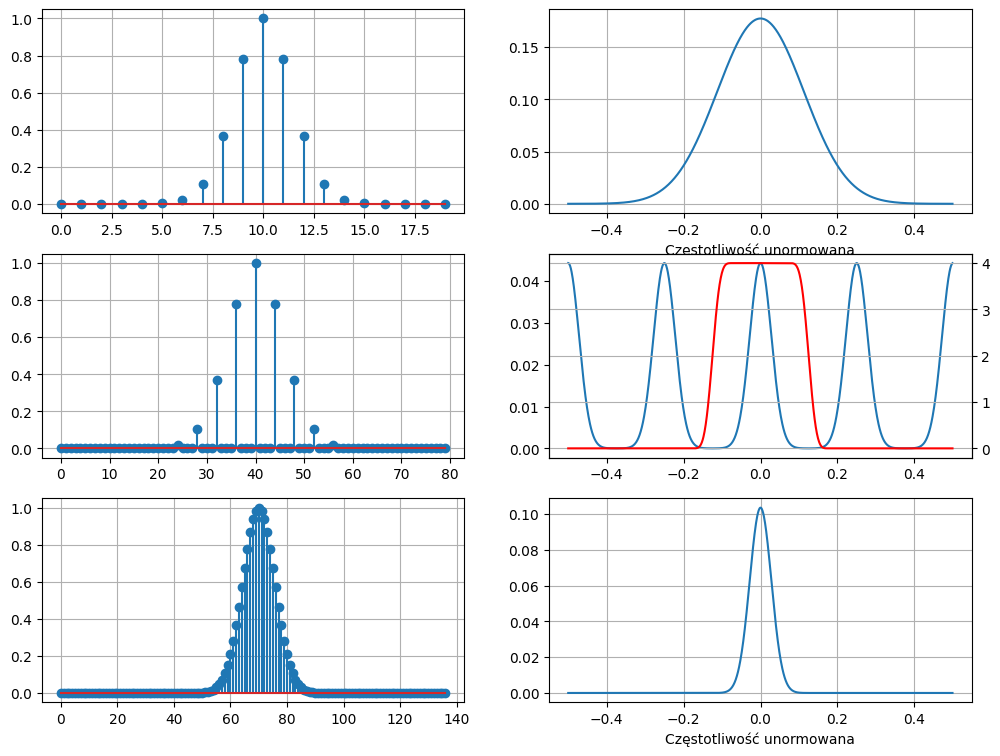

In [ ]:
fs = 1000
T = 1/fs

N = 20
n = np.arange(N)
t = n*T

s = np.exp(-((t-N*T/2)/0.002)**2)

R = 4
s_ = np.zeros(R*s.shape[0])
s_[::R] = s
t_ = np.arange(R*N)*T/R

#b = np.array([1, 1])
b = scipy.signal.firwin(61, 1/R, window='blackman')*R

#si = scipy.signal.convolve(s_, b, mode='same')
si = scipy.signal.upfirdn(b, s, up = R)
#si = scipy.signal.resample_poly(s, up = R, down = 1)


Nfft = 1024
S = np.fft.fftshift(np.fft.fft(s, Nfft))/s.shape[0]
f = np.fft.fftshift(np.fft.fftfreq(Nfft, 1))

S_ = np.fft.fftshift(np.fft.fft(s_, Nfft))/s_.shape[0]
Si = np.fft.fftshift(np.fft.fft(si, Nfft))/si.shape[0]
B = np.fft.fftshift(np.fft.fft(b, Nfft))

plt.figure(figsize=(12,9))

plt.subplot(321)
plt.stem(s)
plt.grid('on')

plt.subplot(322)
plt.plot(f, np.abs(S))
plt.grid('on')
plt.xlabel('Częstotliwość unormowana')

plt.subplot(323)
plt.stem(s_)
plt.grid('on')

plt.subplot(324)
plt.plot(f, np.abs(S_))
ax2 = plt.twinx()
ax2.plot(f, np.abs(B), 'r')
plt.grid('on')
plt.xlabel('Częstotliwość unormowana')

plt.subplot(325)
plt.stem(si)
plt.grid('on')

plt.subplot(326)
plt.plot(f, np.abs(Si))
plt.grid('on')
plt.xlabel('Częstotliwość unormowana')


## Podpróbkowanie

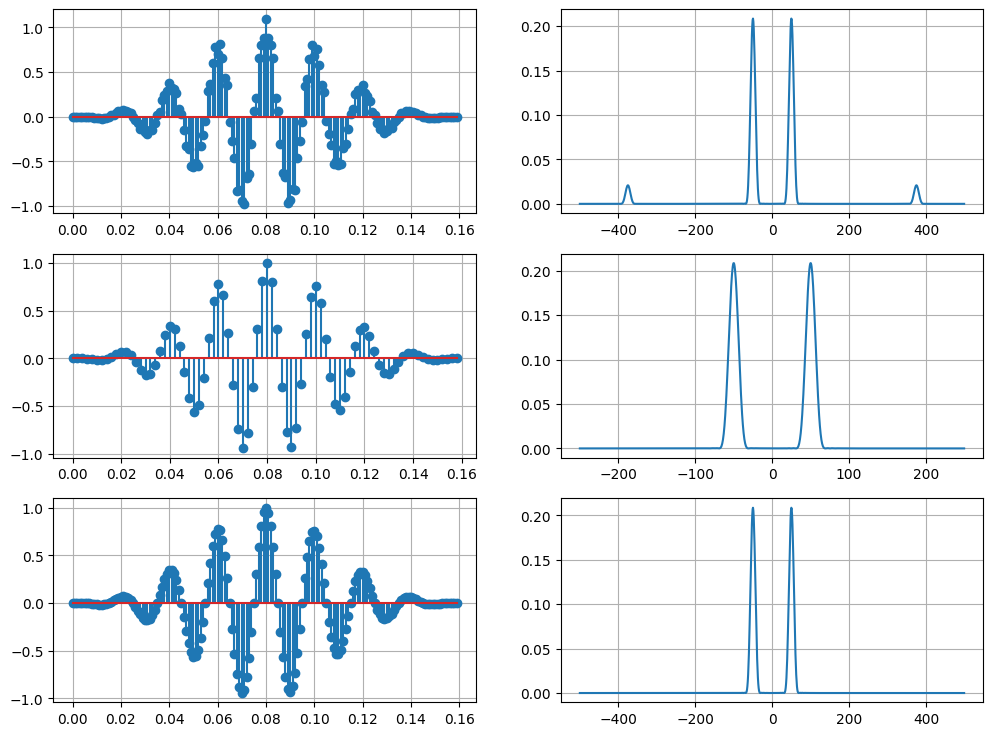

In [ ]:
fs = 1000
T = 1/fs

N = 160
n = np.arange(N)
t = n*T

s = np.cos(2*np.pi*50*t) + 0.1*np.cos(2*np.pi*375*t)
s = s*scipy.signal.windows.blackman(N)

R = 2

b = scipy.signal.firwin(31, 1/R, window='blackman')
slp = scipy.signal.convolve(s, b, mode='same')

#s_ = slp[::R]
s_ = scipy.signal.resample_poly(s, up = 1, down = R)

t_ = t[::R]

si = scipy.signal.resample_poly(s_, up = R, down = 1)

Nfft = 1024
S = np.fft.fftshift(np.fft.fft(s, Nfft))/s.shape[0]
S_ = np.fft.fftshift(np.fft.fft(s_, Nfft))/s_.shape[0]
Si = np.fft.fftshift(np.fft.fft(si, Nfft))/si.shape[0]
f = np.fft.fftshift(np.fft.fftfreq(Nfft, T))
f_ = np.fft.fftshift(np.fft.fftfreq(Nfft, T*R))

plt.figure(figsize = (12, 9))
plt.subplot(321)
plt.stem(t, s)
plt.grid('on')

plt.subplot(322)
plt.plot(f, np.abs(S))
plt.grid('on')

plt.subplot(323)
plt.stem(t_, s_)
plt.grid('on')

plt.subplot(324)
plt.plot(f_, np.abs(S_))
plt.grid('on')

plt.subplot(325)
plt.stem(t, si)
plt.grid('on')

plt.subplot(326)
plt.plot(f, np.abs(Si))
plt.grid('on')